# Getting Started with Qiskit

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ionq-samples/getting-started/blob/main/qiskit.ipynb)

[Qiskit](https://qiskit.org/) is an open-source quantum computing framework developed by IBM for building, simulating, and running quantum circuits on real and simulated quantum devices.

In [2]:
%%capture

# First, we install the essential libraries to our current Python runtime.
# "%%capture" (above) captures and in this case, hides the output of this 
# cell, so you can comment it out if you need help debugging this step.

%pip install qiskit qiskit_ionq matplotlib pylatexenc

In [3]:
import os, qiskit_ionq
from getpass import getpass
import dotenv

dotenv.load_dotenv()

# Before you begin, get your API key from https://cloud.ionq.com/settings/keys
# If your API key is stored as "IONQ_API_KEY" in your local environment, this
# should find it. Otherwise you'll be prompted to enter your API key manually.

api_key = os.getenv('IONQ_API_KEY') or getpass('Enter your IonQ API key: ')
provider = qiskit_ionq.IonQProvider(api_key)
from qiskit_ionq import IonQProvider,ErrorMitigation
print(api_key)
#Call provider and set token value
provider = IonQProvider(token=api_key)
provider.backends()

# We need to specify a backend, which is where the circuit will be executed. In
# this case we're using the `ionq_simulator`, but if you have QPU access you
# can specify it here to run the job on a QPU directly.

qpu_backend = provider.get_backend("qpu.aria-1", gateset="native")

xmWCkOA5c9tZj3PTRFKwmzPR7jFAo7gI


In [ ]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(2, name="Qiskit Example Circuit")
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

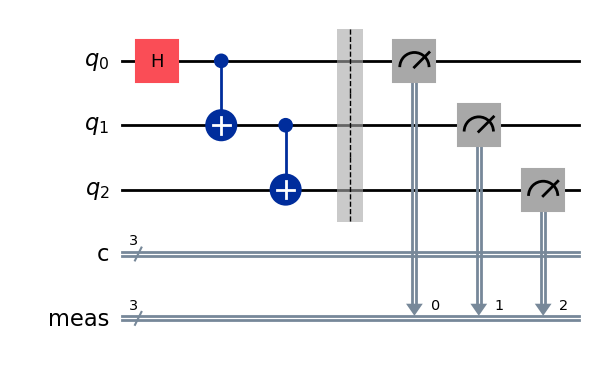

In [12]:
from qiskit import QuantumCircuit


qc = QuantumCircuit(3, 3)
qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)
qc.measure_all()
qc.draw('mpl')

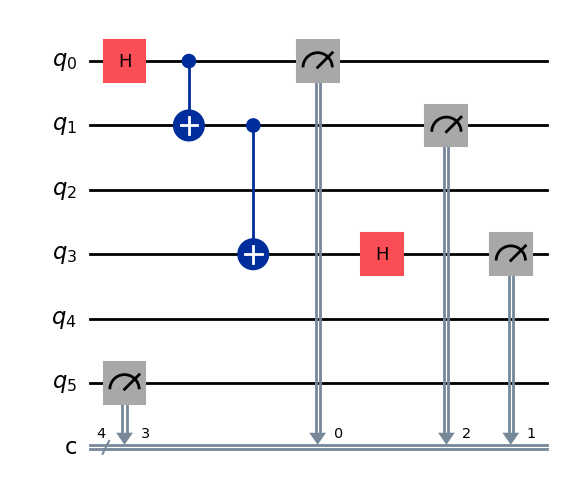

In [15]:
from qiskit import QuantumCircuit
# distorted qc
# Build the distorted GHZ circuit
qc = QuantumCircuit(6, 4)  # 6 qubits, 5 classical bits for config A

qc.h(0)
qc.cx(0, 1)
qc.cx(1, 3)
qc.h(3)

# Configuration A: measure q0, q1, q3, q4, q5
qc.measure(0, 0)  # q0 -> c0
qc.measure(1, 2)  # q1 -> c
qc.measure(3, 1)  # q3 -> c2
qc.measure(5, 3)  # q5 -> c4

qc.draw('mpl')

In [ ]:
## qiskit ideal
from qiskit_aer import AerSimulator
from qiskit import transpile
backend = AerSimulator()
qcT = transpile(qc, backend, optimization_level=3)
job = backend.run(qcT, shots=1000)
counts = job.result().get_counts()
print(counts)

{'0101': 234, '0010': 263, '0000': 255, '0111': 248}


### bit strings 
```
Cloud: {'0000': 436, '1000': 387, '0100': 190, '1100': 796, '0010': 1171, '1010': 731, '0110': 925, '1110': 1303, '0001': 166, '1001': 375, '0101': 666, '1101': 127, '0011': 550, '1011': 1315, '0111': 482, '1111': 380}


Local reference:   {'0000': 824, '1000': 51, '0100': 1220, '1100': 634, '0010': 820, '1010': 351, '0110': 1013, '1110': 775, '0001': 431, '0101': 34, '1101': 592, '0011': 447, '1011': 833, '0111': 222, '1111': 508, '1001': 1245}

```

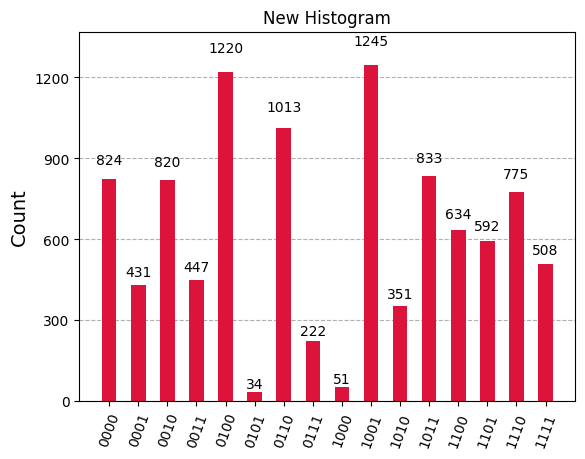

In [9]:
from qiskit.visualization import plot_histogram
good = {'0000': 824, '1000': 51, '0100': 1220, '1100': 634, '0010': 820, '1010': 351, '0110': 1013, '1110': 775, '0001': 431, '0101': 34, '1101': 592, '0011': 447, '1011': 833, '0111': 222, '1111': 508, '1001': 1245}
plot_histogram(good, color=['crimson','midnightblue'],
                title="New Histogram")

In [20]:
# ionq noisy
job = ionq_local.run(qcT, shots=1000, noise_model="aria-1")
print(job.get_counts())

{'0000': np.int64(245), '0001': np.int64(2), '0100': np.int64(1), '0101': np.int64(290), '0010': np.int64(232), '0011': np.int64(2), '0111': np.int64(228)}


In [19]:
## ionq ideal
from qiskit_aer import AerSimulator
from qiskit import transpile
ionq_local = provider.get_backend("simulator", gateset="qis")
backend = AerSimulator()
qcT = transpile(qc, ionq_local, optimization_level=3)
job = ionq_local.run(qcT, shots=1000)
counts = job.get_counts()
print(counts)

/pscratch/sd/g/gzquse/cudaq/lib/python3.11/site-packages/qiskit/providers/backend_compat.py:153: RuntimeWarning: No gate definition for mcx can be found and is being excluded from the generated target. You can use `custom_name_mapping` to provide a definition for this operation.
  warnings.warn(
/pscratch/sd/g/gzquse/cudaq/lib/python3.11/site-packages/qiskit/providers/backend_compat.py:153: RuntimeWarning: No gate definition for cnot can be found and is being excluded from the generated target. You can use `custom_name_mapping` to provide a definition for this operation.
  warnings.warn(
/pscratch/sd/g/gzquse/cudaq/lib/python3.11/site-packages/qiskit/providers/backend_compat.py:153: RuntimeWarning: No gate definition for mcp can be found and is being excluded from the generated target. You can use `custom_name_mapping` to provide a definition for this operation.
  warnings.warn(
/pscratch/sd/g/gzquse/cudaq/lib/python3.11/site-packages/qiskit/providers/backend_compat.py:153: RuntimeWarn

{'0000': np.int64(260), '0101': np.int64(238), '0010': np.int64(268), '0111': np.int64(234)}


In [ ]:
# ionq cloud distorted 
job = qpu_backend.retrieve_job("01983dd1-1dc2-748a-840c-692bd6c18eff")
job.status()
job.get_counts()

{'0000': 259,
 '0001': 7,
 '0100': 8,
 '0101': 232,
 '0010': 267,
 '0011': 6,
 '0110': 5,
 '0111': 216}

In [25]:
# circuit analysis
from qiskit.visualization import plot_histogram
from qiskit import transpile
ionq_local = provider.get_backend("simulator")
ion_qpu = provider.get_backend("qpu.aria-1", gateset="native")

qcT =  transpile(qc, ion_qpu, optimization_level=3)
ionq_transpiled = transpile(qc, ion_qpu)
print("IonQ transpiled depth:", ionq_transpiled.depth())
local_transpiled = transpile(qc, ionq_local)  
print("Local transpiled depth:", local_transpiled.depth())

print("Same number of operations?", len(ionq_transpiled.data) == len(local_transpiled.data))

IonQ transpiled depth: 11
Local transpiled depth: 4
Same number of operations? False


/pscratch/sd/g/gzquse/cudaq/lib/python3.11/site-packages/qiskit/providers/backend_compat.py:153: RuntimeWarning: No gate definition for mct can be found and is being excluded from the generated target. You can use `custom_name_mapping` to provide a definition for this operation.
  warnings.warn(
/pscratch/sd/g/gzquse/cudaq/lib/python3.11/site-packages/qiskit/providers/backend_compat.py:153: RuntimeWarning: No gate definition for mcp can be found and is being excluded from the generated target. You can use `custom_name_mapping` to provide a definition for this operation.
  warnings.warn(
/pscratch/sd/g/gzquse/cudaq/lib/python3.11/site-packages/qiskit/providers/backend_compat.py:153: RuntimeWarning: No gate definition for mcx can be found and is being excluded from the generated target. You can use `custom_name_mapping` to provide a definition for this operation.
  warnings.warn(
/pscratch/sd/g/gzquse/cudaq/lib/python3.11/site-packages/qiskit/providers/backend_compat.py:153: RuntimeWarni

In [17]:
print(local_transpiled)

        ┌─────────┐┌─────────────┐┌───────────┐┌────────────┐┌───────────────┐»
   q_0: ┤ Gpi2(0) ├┤ Gpi(-0.125) ├┤ Gpi2(0.5) ├┤ Gpi2(0.25) ├┤0              ├»
        └─────────┘└─────────────┘└───────────┘└────────────┘│  Ms(0,0,0.25) │»
   q_1: ─────────────────────────────────────────────────────┤1              ├»
                                                             └───────────────┘»
   q_2: ──────────────────────────────────────────────────────────────────────»
                                                                              »
   c: 3/══════════════════════════════════════════════════════════════════════»
                                                                              »
meas: 3/══════════════════════════════════════════════════════════════════════»
                                                                              »
«        ┌───────────┐┌─────────────┐                              »
«   q_0: ┤ Gpi2(0.5) ├┤ Gpi2(-0.25) ├──────────────

In [8]:
# Check what's actually being executed
print("IonQ operations:")
for i, instruction in enumerate(ionq_transpiled.data):
    if instruction[0].name != 'measure':
        print(f"{i}: {instruction[0].name} on qubits {[q.index for q in instruction[1]]}")

print("\nLocal operations:")  
for i, instruction in enumerate(local_transpiled.data):
    if instruction[0].name != 'measure':
        print(f"{i}: {instruction[0].name} on qubits {[q.index for q in instruction[1]]}")

IonQ operations:


/tmp/ipykernel_806282/1842235089.py:4: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  if instruction[0].name != 'measure':
/tmp/ipykernel_806282/1842235089.py:5: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  print(f"{i}: {instruction[0].name} on qubits {[q.index for q in instruction[1]]}")


AttributeError: 'Qubit' object has no attribute 'index'

In [ ]:
job = ion_qpu.run(qcT, shots=1000, error_mitigation=ErrorMitigation.NO_DEBIASING)
job.status()

<JobStatus.DONE: 'job has successfully run'>

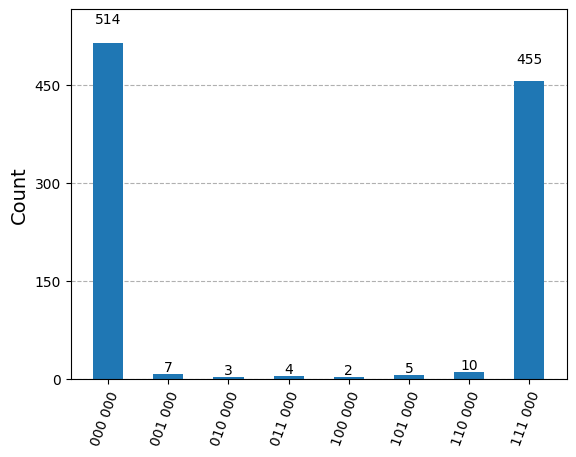

In [17]:
plot_histogram(job.result().get_counts())

## And that's a wrap!

To continue learning with Qiskit, check out more advanced examples here: https://github.com/ionq-samples/qiskit-getting-started